In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

In [12]:
root_dir = Path.cwd().parent
data_dir = root_dir / "data" / "raw" / "urbaneats-dataset.csv"

In [13]:
df = pd.read_csv(data_dir)

In [14]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


# Initial Analysis

In [17]:

# shape of data

rows, cols = df.shape

print("The dataset has {} rows and {} columns".format(rows,cols))
     

The dataset has 45593 rows and 20 columns


In [19]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

Corrections:

Age column should be numerical.

Ratings should be float.

Date and time columns should be date and time.

Vehicle conditions seems to be categorical column which is integer encoded.

Multiple deliveries should be integer column.

Target column should also be numbers.

In [21]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [23]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

Seems Like There are no missing values in the dataset.

In [25]:
df.sample(50)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
43056,0xb860,INDORES12DEL02,29,4.4,22.748060,75.893400,22.878060,76.023400,18-03-2022,19:25:00,19:40:00,conditions Cloudy,Jam,2,Meal,motorcycle,0,No,Metropolitian,(min) 32
24249,0x4d45,CHENRES16DEL03,30,5,13.049645,80.242268,13.079645,80.272268,03-04-2022,23:00:00,23:10:00,conditions Cloudy,Low,2,Meal,scooter,1,No,Metropolitian,(min) 19
33356,0x6f6e,INDORES01DEL01,20,4.8,22.695207,75.866059,22.705207,75.876059,15-03-2022,09:30:00,09:35:00,conditions Fog,Low,1,Meal,scooter,1,No,Metropolitian,(min) 11
14108,0x7995,MUMRES15DEL03,32,4.2,19.176269,72.836721,19.236269,72.896721,07-03-2022,18:10:00,18:25:00,conditions Windy,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 34
21879,0x184b,VADRES03DEL01,29,4.9,22.320000,73.170000,22.360000,73.210000,28-03-2022,15:00:00,15:10:00,conditions Sandstorms,High,2,Meal,scooter,0,No,Urban,(min) 11
18940,0x8fb4,COIMBRES15DEL02,38,4.6,11.006686,76.951736,11.056686,77.001736,26-03-2022,19:15:00,19:25:00,conditions Sandstorms,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 46
30512,0xa3cf,RANCHIRES11DEL01,22,5,23.359194,85.325447,23.399194,85.365447,01-04-2022,16:35:00,16:50:00,conditions Sandstorms,Medium,2,Meal,scooter,0,No,Urban,(min) 25
44995,0x82ea,MYSRES12DEL02,33,3.5,12.284747,76.625861,12.364747,76.705861,12-03-2022,18:35:00,18:50:00,conditions Windy,Medium,2,Buffet,scooter,1,No,Metropolitian,(min) 33
24982,0xd3db,LUDHRES07DEL03,22,4.6,0.000000,0.000000,0.090000,0.090000,12-02-2022,18:30:00,18:35:00,conditions Windy,Medium,2,Buffet,scooter,0,No,Metropolitian,(min) 15
32842,0x361c,PUNERES13DEL01,38,4.1,18.562450,73.916619,18.672450,74.026619,12-03-2022,20:40:00,20:45:00,conditions Sunny,Jam,0,Meal,motorcycle,1,No,Metropolitian,(min) 32


Few Observation from the sample:

I have NAN values in the dataset but still df.isna().sum() and df.isnull().sum() is giving zero. Need to investigate.

Restaurant and Delivery Locations have absurd 0.000 lat and long info , which points to equator.

I can see the age is 15 on some cases , which shows the signs of child labour. Need to investigate further.

the first 4 letters of the column delivery person id has the information of City. I can Perform feature extraction to extract the city info.

City column in the orginal dataset have values like metropolitan, urban which can confuse in further stages. Maybe I can rename the column to city type or something like that.

Weather Conditions Column has Condition NAN as a weather condition. I need to do rework to extract the NAN values and treat it.

# Inspecting Missing Values

In [28]:
df.loc[43317,"Delivery_person_Ratings"]

'NaN '

In [29]:
type(df.loc[43317,"Delivery_person_Ratings"])

str

Null values are stored as string values like 'NaN '. Hence I was not able to see them prior to this. Need to treat this.

In [33]:
(df == "NaN ").sum().sum()

np.int64(8515)

In [34]:
(df == "NaN ").sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [35]:
df.replace("NaN ",np.nan,inplace=True)

In [38]:
df.isna().sum().sum()

np.int64(8515)

In [39]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

Hence there are total of 8515 missing value present in the dataset. I need to treat them individually.

Now Handling NaN Columns in Weather Conditions Column which is disguised as condition NaN

In [41]:
df['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [42]:
df[df['Weatherconditions'] == "conditions NaN"]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
74,0xa9f,BANGRES13DEL01,NaN,NaN,12.935662,77.614130,12.975662,77.654130,11-03-2022,NaN,15:30:00,conditions NaN,NaN,1,Drinks,scooter,0,No,Metropolitian,(min) 19
120,0x6e2,VADRES06DEL01,NaN,NaN,22.312790,73.170283,22.422790,73.280283,02-04-2022,NaN,18:25:00,conditions NaN,NaN,3,Snack,electric_scooter,0,No,Metropolitian,(min) 25
250,0x1b50,PUNERES16DEL01,NaN,NaN,18.536718,73.830327,18.646718,73.940327,08-03-2022,NaN,21:25:00,conditions NaN,NaN,3,Buffet,motorcycle,1,Yes,Urban,(min) 43
348,0x4c1,BANGRES13DEL02,NaN,NaN,12.935662,77.614130,13.065662,77.744130,02-03-2022,NaN,00:05:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 26
425,0xc003,DEHRES13DEL02,NaN,NaN,-30.366322,-78.070453,30.496322,78.200453,18-02-2022,NaN,22:30:00,conditions NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45332,0x2950,VADRES04DEL02,50,6,0.000000,0.000000,0.020000,0.020000,19-03-2022,NaN,10:40:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Urban,(min) 28
45394,0xdc4,RANCHIRES02DEL03,NaN,NaN,0.000000,0.000000,0.030000,0.030000,05-03-2022,NaN,17:25:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 21
45504,0x461,BANGRES07DEL02,NaN,NaN,-12.978453,-77.643685,12.998453,77.663685,17-03-2022,NaN,09:30:00,conditions NaN,NaN,3,Meal,scooter,1,No,NaN,(min) 24
45518,0x863,INDORES05DEL01,NaN,NaN,22.727021,75.884167,22.737021,75.894167,19-03-2022,NaN,11:40:00,conditions NaN,NaN,3,Snack,electric_scooter,0,No,Metropolitian,(min) 25


In [44]:
df[df['Weatherconditions'] == "conditions NaN"]['Weatherconditions'].replace('conditions NaN',np.nan,inplace=True)

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_5924\3386415797.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[df['Weatherconditions'] == "conditions NaN"]['Weatherconditions'].replace('conditions NaN',np.nan,inplace=True)
C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_5924\3386415797.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['Weatherconditions'] == "conditions NaN"]['Weatherconditions'].replace('conditions NaN',np.nan,inplace=True)


Above code creates a temporary copy. Hence saw this error. I'll try to use loc.

In [48]:
df.loc[
    df['Weatherconditions'] == "conditions NaN",
    'Weatherconditions'
] = np.nan

In [49]:
df.isna().sum().sum()

np.int64(9131)

In [50]:
8515 + 616

9131

In [51]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

# Missing Value Analysis

In [52]:
missing_df = df.copy()

In [53]:
missing_df.shape

(45593, 20)

<Axes: >

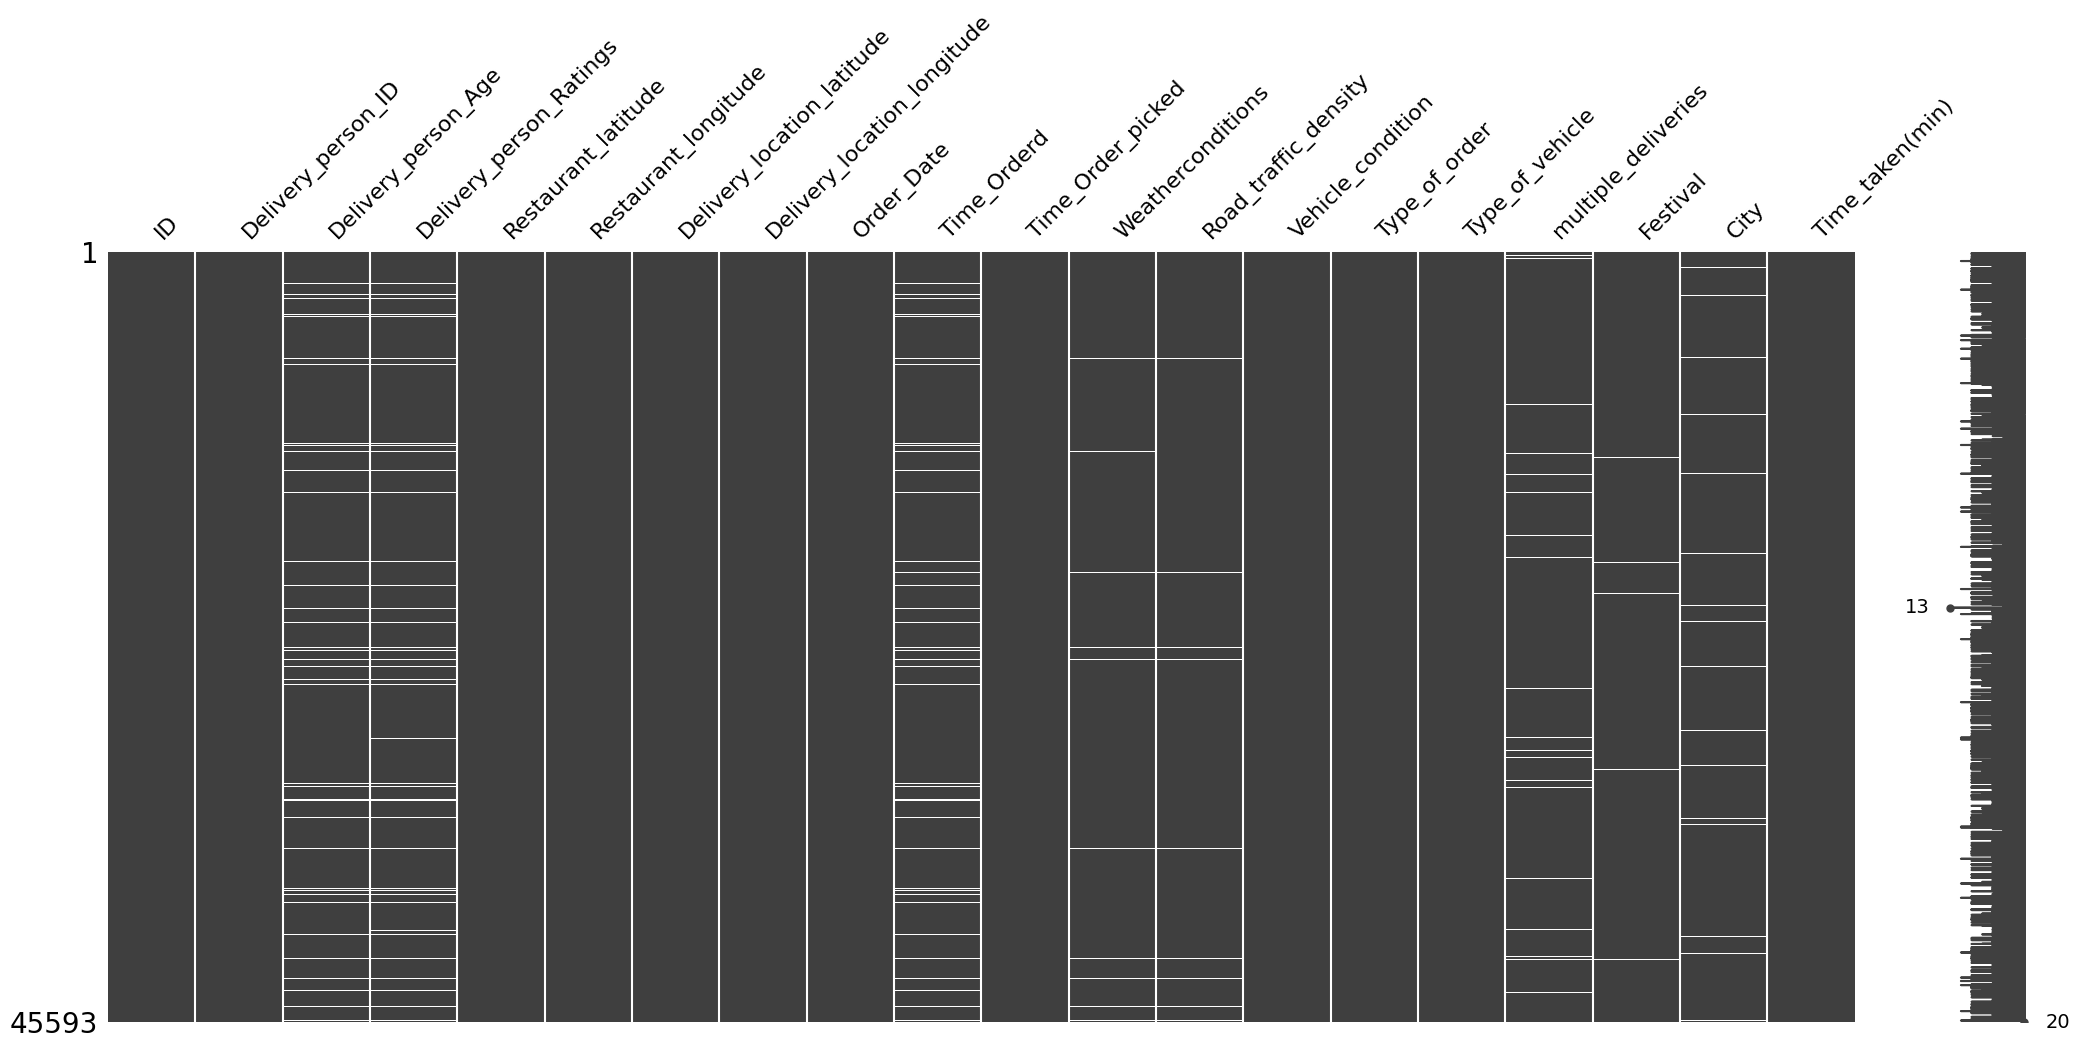

In [54]:
msno.matrix(missing_df)

<Axes: >

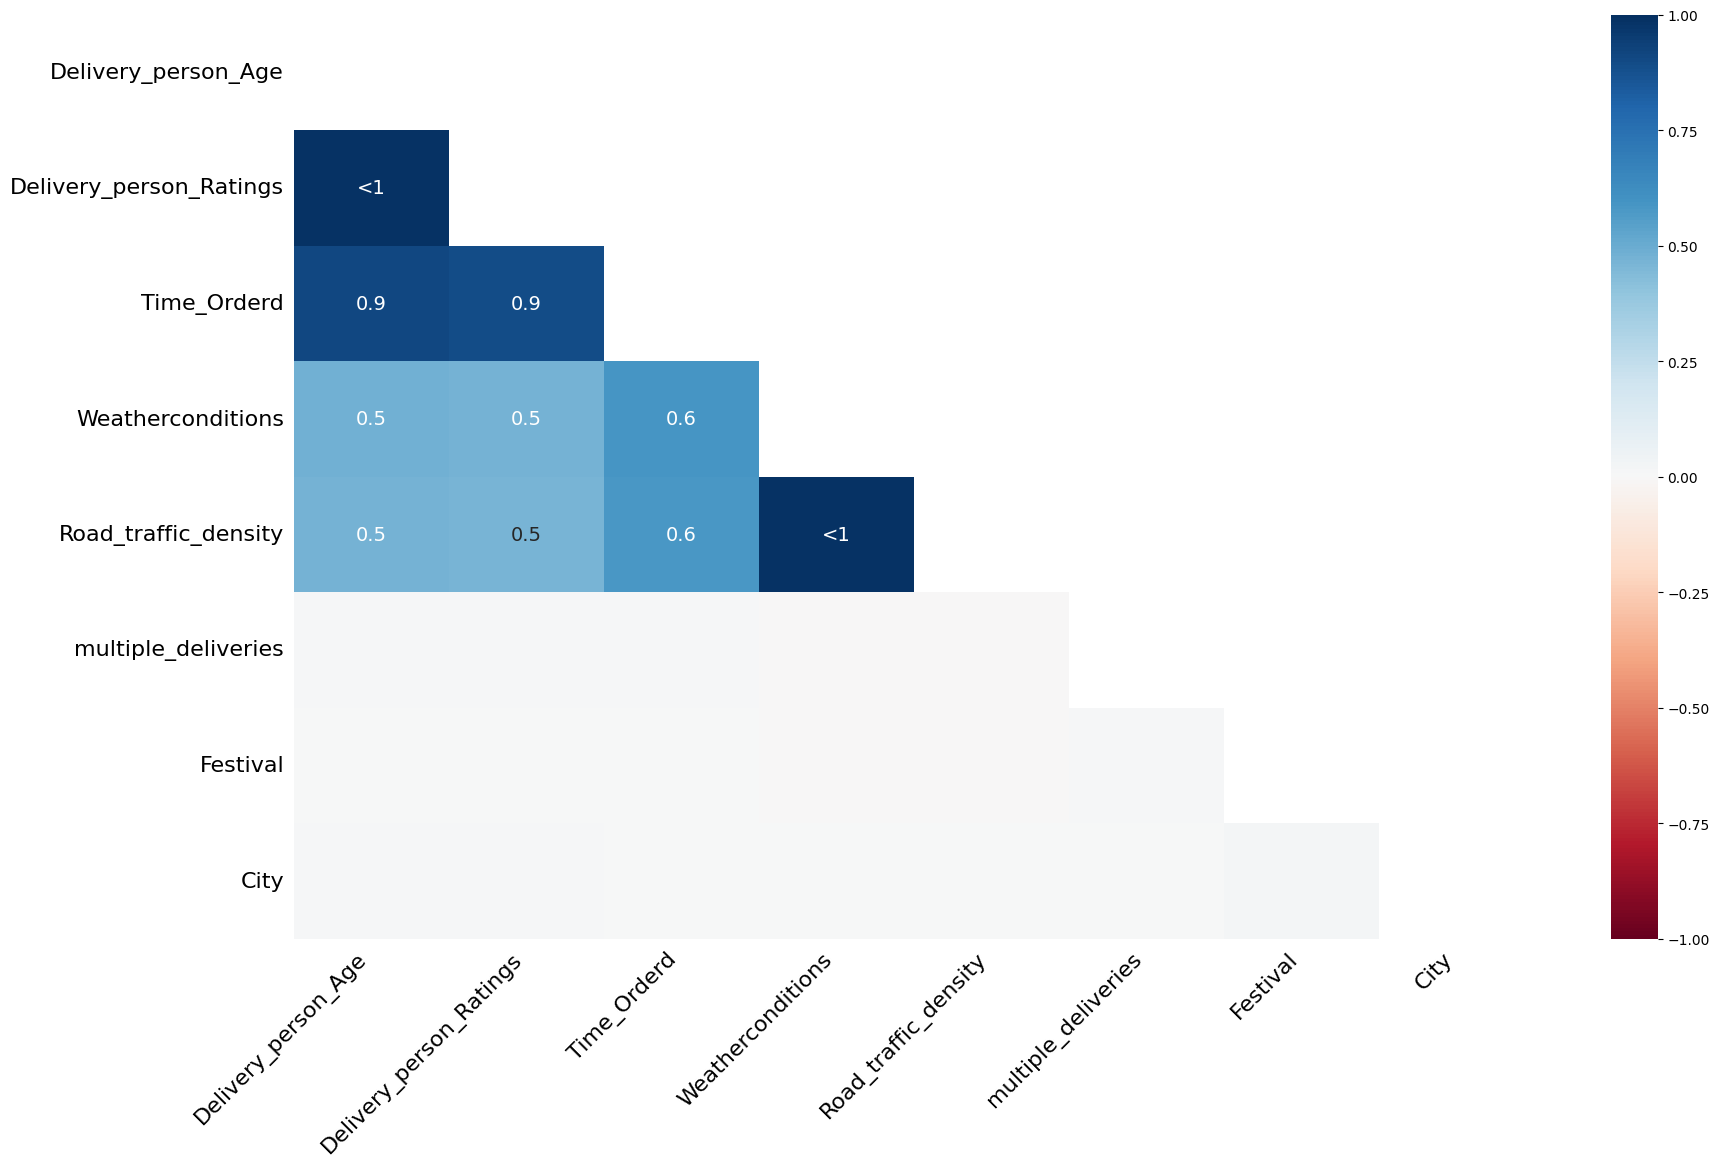

In [55]:
msno.heatmap(missing_df)

<Axes: >

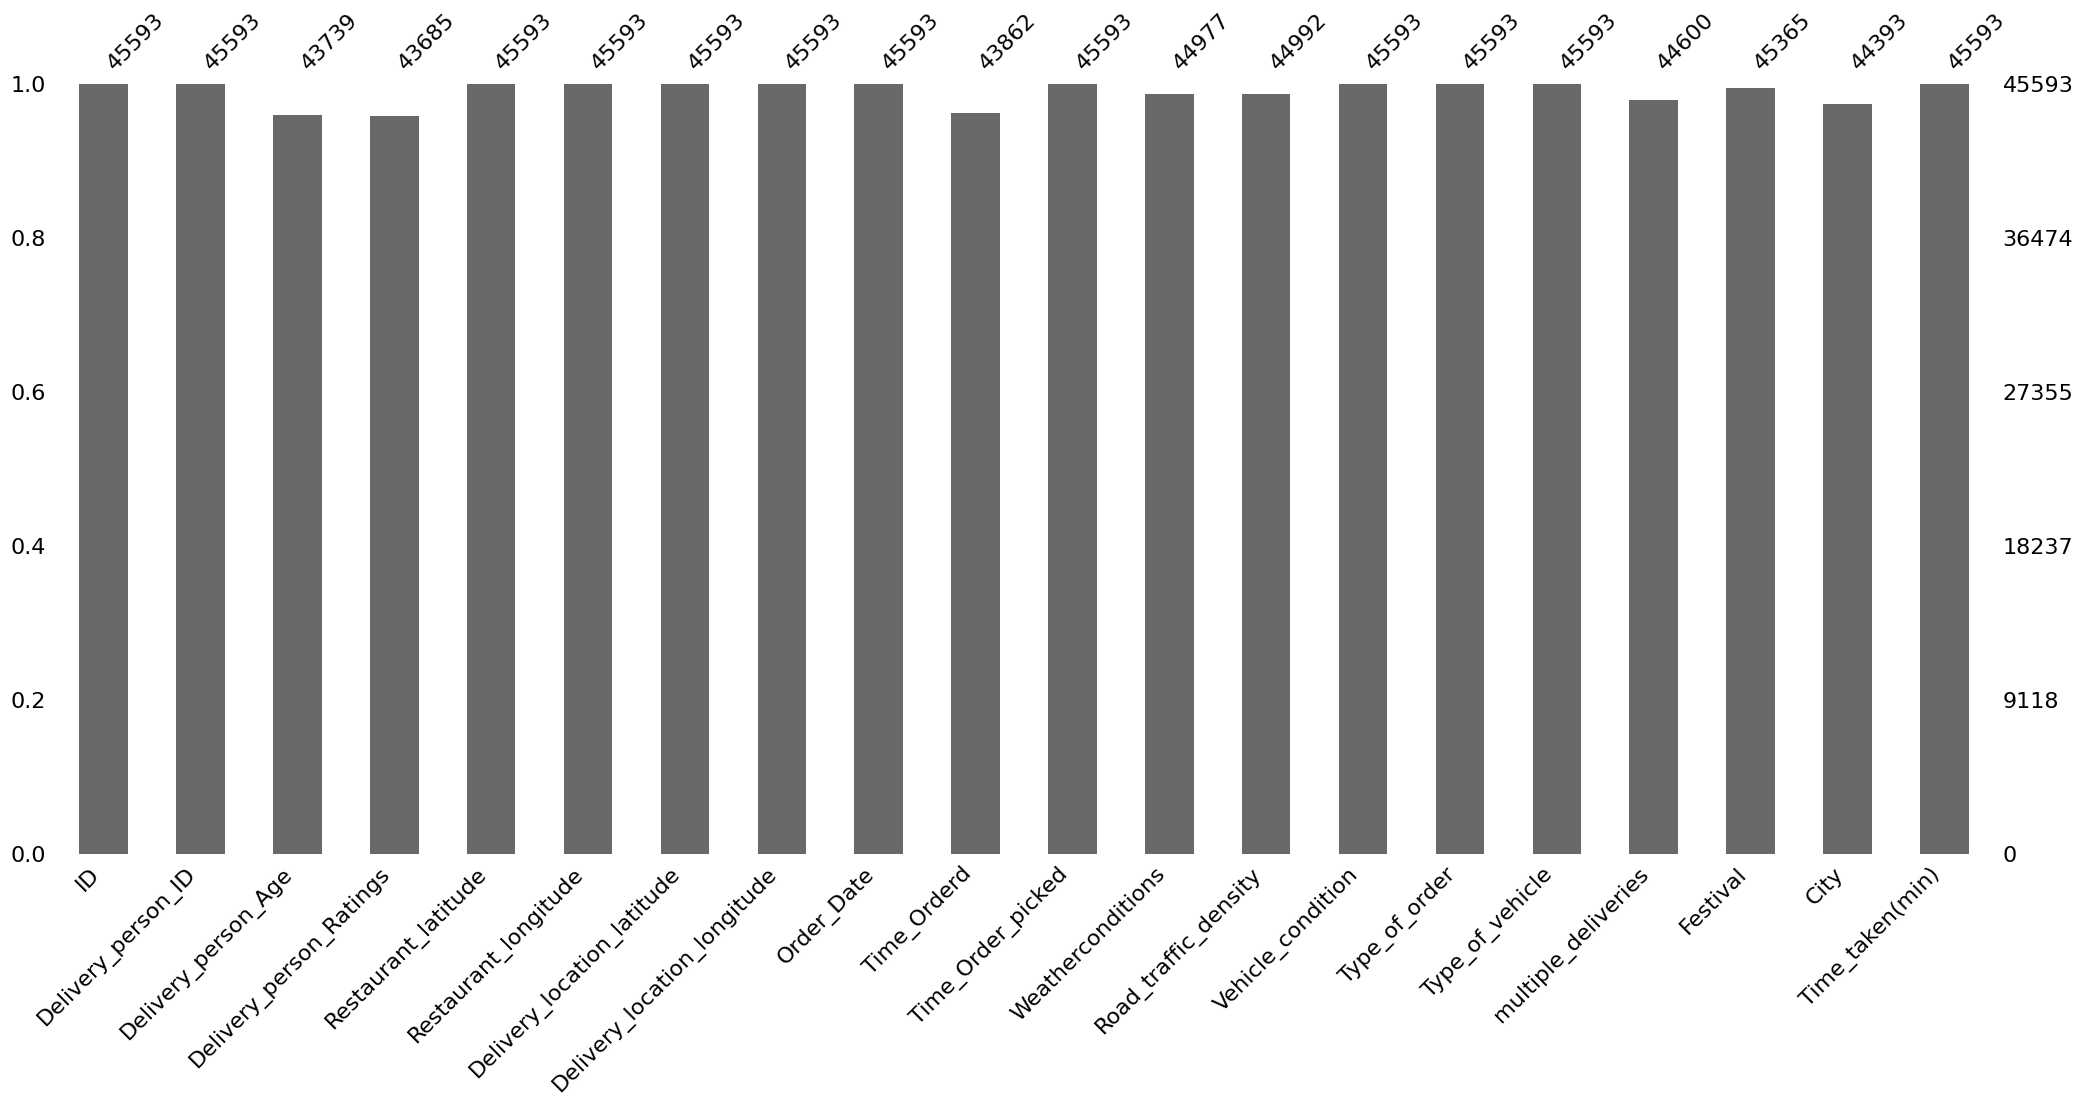

In [56]:
msno.bar(missing_df)

Observations

The delivery person columns are correlated to each other. This means that missingness in these columns is highly related which means lack of rider data.

The time ordered column is also related to the rider which shows that the data might be missing due to some network error where the system was unable to log rider details and time of order.

There is a very high correlation between weather patterns and the road traffic information. Be clear that this does not mean that the road traffic and weather columns are correlated. High corr in missingness means that if value in one column is missing, it is a high chance that it will be missing in others as well.

Road traffic density also shows correlation to the rider as it might be provided through the phone of rider (need to investigate).

<Axes: >

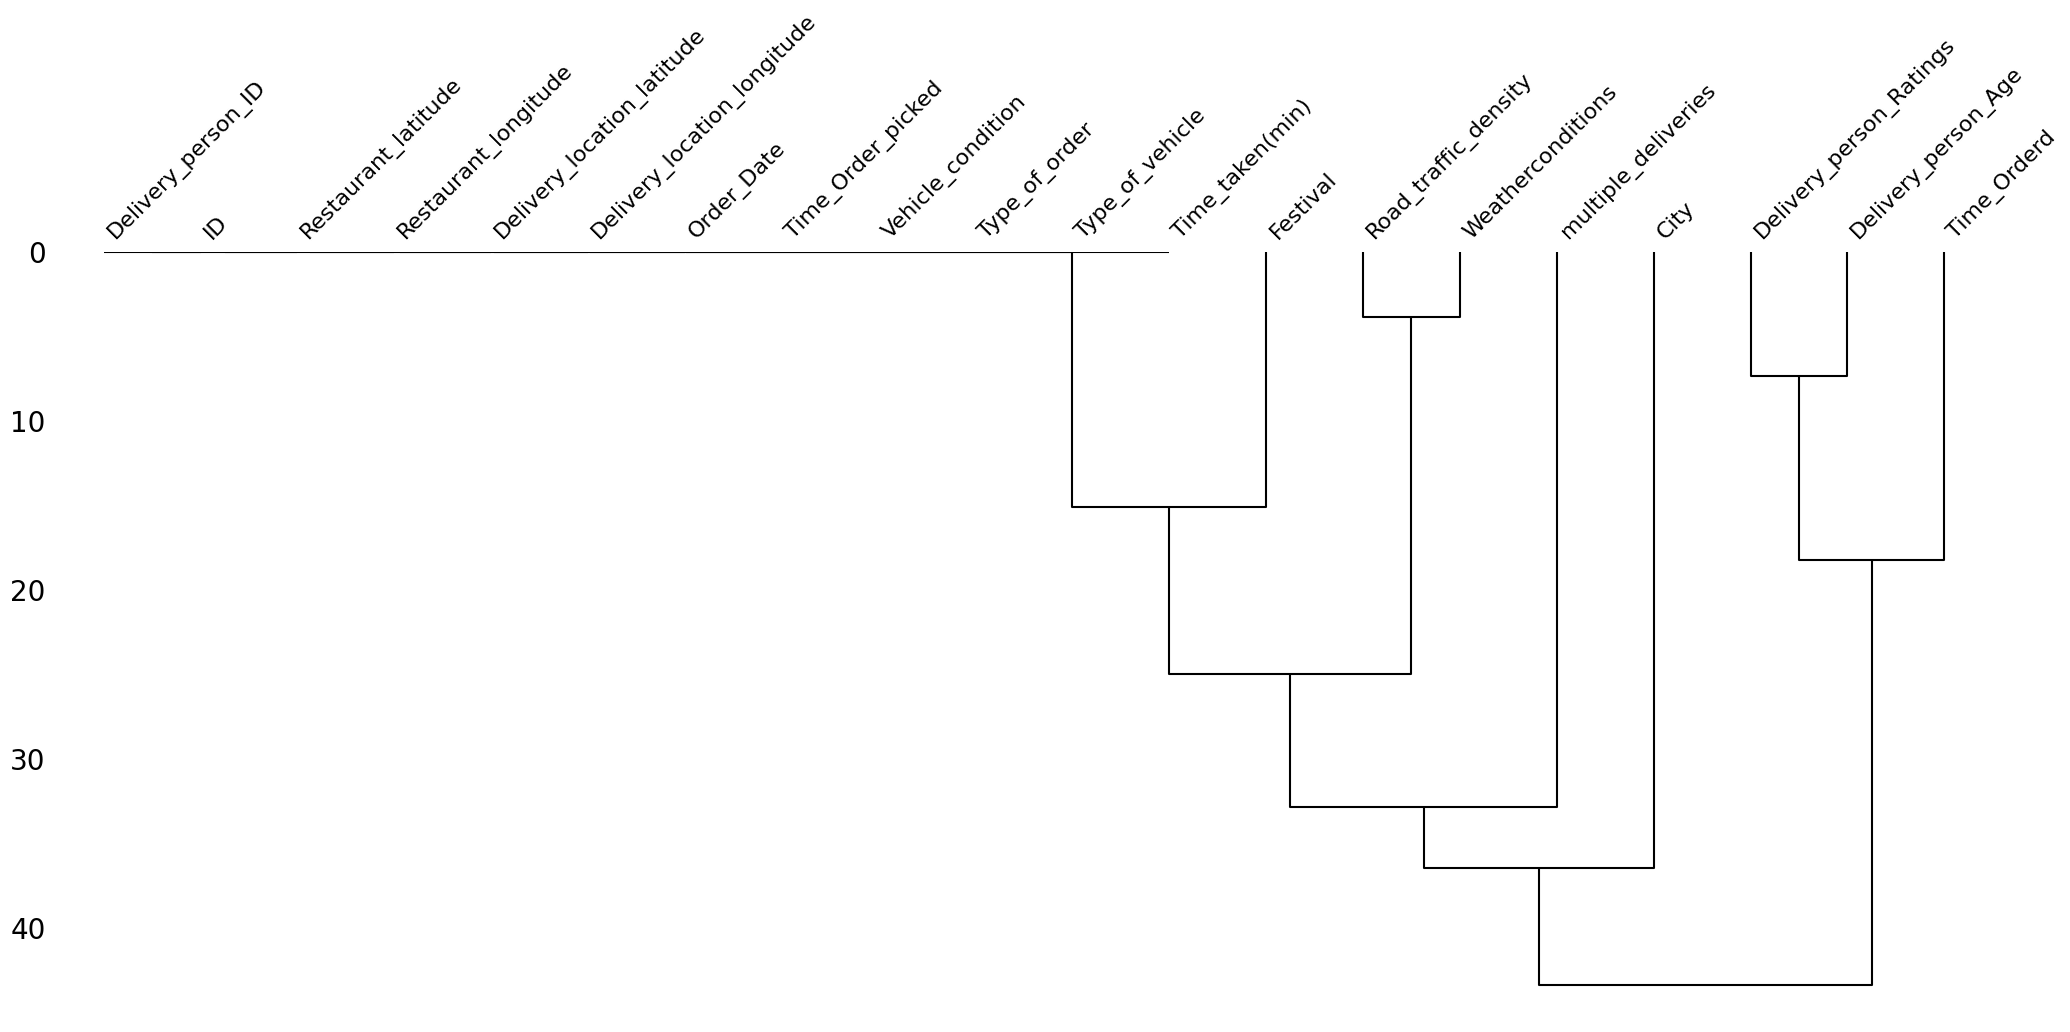

In [57]:
msno.dendrogram(missing_df)

In [61]:
# Missing Rows in the dataset
(missing_df.isna().any(axis=1).sum() / missing_df.shape[0])*100

np.float64(9.266773408198627)

Around __9%__ of the rows consist of a missing value across the entire dataset. 

# Phase 1: Data Cleaning

In [67]:
df.columns.to_list()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken(min)']

In [68]:
def change_column_names(data: pd.DataFrame):
    return (
        data.rename(str.lower,axis=1)
        .rename({
            "delivery_person_id" : "rider_id",
            "delivery_person_age": "age",
            "delivery_person_ratings": "ratings",
            "delivery_location_latitude": "delivery_latitude",
            "delivery_location_longitude": "delivery_longitude",
            "time_orderd": "order_time",
            "time_order_picked": "order_picked_time",
            "weatherconditions": "weather",
            "road_traffic_density": "traffic",
            "city": "city_type",
            "time_taken(min)": "time_taken"},axis=1)
    )

In [70]:

# change column names

df = change_column_names(df)

In [71]:
df.head(5)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df[['id','rider_id']].duplicated().sum()

np.int64(0)

There are no Duplicate rows in the Dataset

# Column Wise Cleaning

# id

In [75]:
df['id'].nunique()

45593

All the ID values are unique. But we can drop this column.

# rider_id

In [76]:
df['rider_id'].nunique()

1320

In [77]:
df['rider_id'].value_counts()

rider_id
PUNERES01DEL01       67
JAPRES11DEL02        67
VADRES08DEL02        66
RANCHIRES02DEL01     66
HYDRES04DEL02        66
                     ..
BHPRES15DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64

__1320__ unique riders are present. the first 4 charachters represent city.

In [93]:
df['rider_id'].str.split('RES').str.get(0).rename('city')

0          INDO
1          BANG
2          BANG
3         COIMB
4          CHEN
          ...  
45588       JAP
45589       AGR
45590      CHEN
45591     COIMB
45592    RANCHI
Name: city, Length: 45593, dtype: object

# age

In [94]:
df['age'].dtype

dtype('O')

Age column must be an integer value.

In [97]:
df['age'].isna().sum()

np.int64(1854)

In [98]:
df['age'].astype(float).describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

Investigating 15 age of the rider.

In [103]:
df[df['age'] == '15'].shape

(38, 20)

In [105]:
underage_df = df[df['age'] == '15']

In [106]:
underage_df.isna().sum()

id                       0
rider_id                 0
age                      0
ratings                  0
restaurant_latitude      0
restaurant_longitude     0
delivery_latitude        0
delivery_longitude       0
order_date               0
order_time              38
order_picked_time        0
weather                 38
traffic                 38
vehicle_condition        0
type_of_order            0
type_of_vehicle          0
multiple_deliveries      0
festival                 0
city_type                0
time_taken               0
dtype: int64

Observations:

The star ratings of all the riders is 1.

The vehicle condition of these riders is very bad.

No weather and traffic conditions available.

Age of all these riders is 15 which is below the permissable age to drive a vehicle.

Latitude and Longitude values in negative which is not possible. India is situated above the equator so all latitudes should be positive and east of meridian line so longitudes are positive as well.

__Seems like removing this data for now makes more sense then fixing it because a lot of data is missing__

# ratings

In [107]:
df['ratings'].dtype

dtype('O')

In [109]:
df['ratings'].isna().sum()

np.int64(1908)

In [110]:
df['ratings'].astype(float).describe()

count    43685.000000
mean         4.633780
std          0.334716
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

In [115]:
six_star_df = df[df['ratings'] == '6']

In [116]:
six_star_df.shape

(53, 20)

__6 star rating is possibly a data error__

Investigate further before action

Data removal seems logical at this stage.

<Axes: ylabel='ratings'>

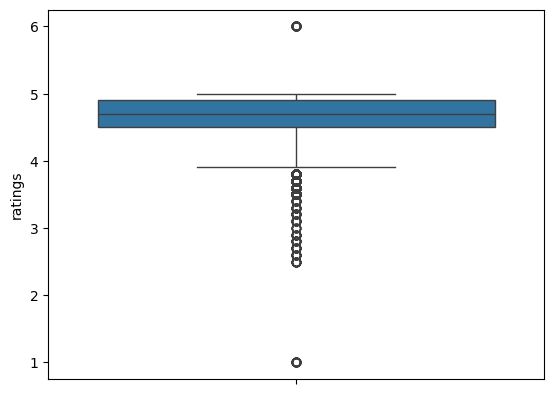

In [113]:
sns.boxplot(df['ratings'].astype(float))

The Minors data have ratings as 1 which seems like an anomaly if we generally consider the ratings column distribution.

The rating of 6 is also one another anomaly in the data as maximum ratings are 5 and not more than that

Has to be investigated
If data is problematic than fixing or removing is an option

# Locations Columns
1. restaurant_latitude
2. restaurant_longitude
3. delivery_latitude
4. delivery_longitude

In [117]:

location_columns = df.columns[4:8].tolist()

location_columns

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [118]:

location_subset = df.loc[:,location_columns]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
45588,26.902328,75.794257,26.912328,75.804257
45589,0.000000,0.000000,0.070000,0.070000
45590,13.022394,80.242439,13.052394,80.272439
45591,11.001753,76.986241,11.041753,77.026241


Valid values for lat and long

India lies to the north of the equator between 6° 44′ and 35° 30′ north latitude and 68° 7′ and 97° 25′ east longitude.

In [120]:
location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


Max Values are still fine , But I need to check about min values which are negative and are zero crossing the threshold

In [125]:
lat_lb = 6.44
long_lb = 68.70

In [129]:
location_anamoly = location_subset.loc[
    (location_subset['restaurant_latitude'] < lat_lb) |
    (location_subset['restaurant_longitude'] < long_lb) |
    (location_subset['delivery_latitude'] < lat_lb) |
    (location_subset['delivery_longitude'] < long_lb)
]

In [130]:
location_anamoly.shape

(4071, 4)

__There are 4071 rows in the data where the lat long columns are messy__

In [131]:
location_anamoly.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,4071.000000,4071.000000,4071.000000,4071.000000
mean,-2.149416,2.068601,2.212538,8.299885
std,6.537913,25.270676,6.538283,23.980011
min,-30.905562,-88.366217,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.523452


Restaurant Latitude is having the max value of zero , among the anamolies dataset which is concerning.

(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

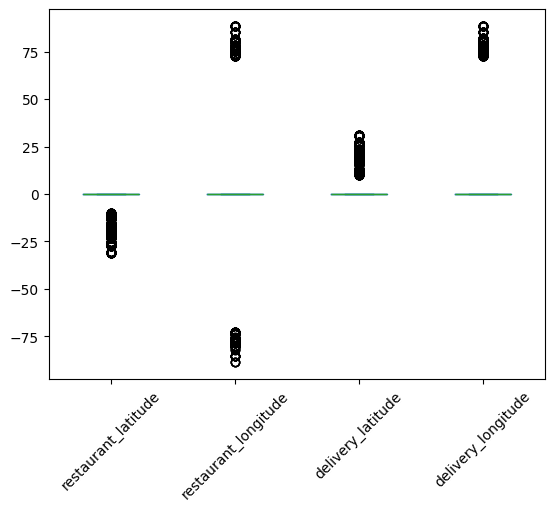

In [133]:
location_anamoly.plot(kind = 'box')
plt.xticks(rotation=45)

__I can see scaling as an issue. Maybe I can try scaling the values. But still It wont solve zero Lat problem.__

Performing the Below Step for the entire dataset not only for anamolous columns

In [153]:
location_anamoly_scaled = location_subset.abs()

In [154]:
location_anamoly_scaled.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.401571,70.782088,17.465186,70.845702
std,7.333766,21.118611,7.335122,21.118812
min,0.000000,0.000000,0.010000,0.010000
25%,12.934179,73.170283,12.988453,73.280000
50%,18.554382,75.898497,18.633934,76.002574
75%,22.732225,78.046106,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


[Text(1, 0, 'restaurant_latitude'),
 Text(2, 0, 'restaurant_longitude'),
 Text(3, 0, 'delivery_latitude'),
 Text(4, 0, 'delivery_longitude')]

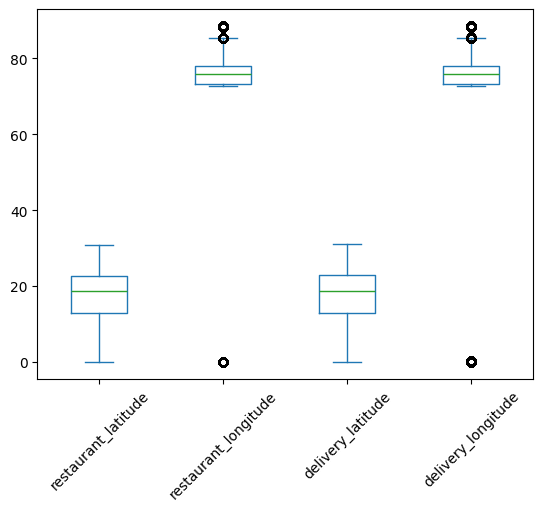

In [155]:
location_anamoly_scaled.plot(kind='box')
ax = plt.gca()

ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

__I can mak zero values as np.nan (missing values) , as I may need to impute the values.__

In [158]:
location_anamoly_after_scaling = location_anamoly_scaled.loc[
    (location_anamoly_scaled['restaurant_latitude'] < lower_bound_lat) |
    (location_anamoly_scaled['restaurant_longitude'] < lower_bound_long) |
    (location_anamoly_scaled['delivery_latitude'] < lower_bound_lat) |
    (location_anamoly_scaled['delivery_longitude'] < lower_bound_long)
]

In [159]:
location_anamoly_after_scaling.shape

(3640, 4)

__3640 rows in the data that have messy lat long values__

In [160]:
location_subset.abs().loc[lambda df_:
                        (df_['restaurant_latitude'] < 1) |
                        (df_['restaurant_longitude'] < 1) |
                        (df_['delivery_latitude'] < 1) |
                        (df_['delivery_longitude'] < 1)]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
33,0.0,0.0,0.11,0.11
52,0.0,0.0,0.03,0.03
57,0.0,0.0,0.08,0.08
59,0.0,0.0,0.06,0.06
67,0.0,0.0,0.02,0.02
...,...,...,...,...
45569,0.0,0.0,0.07,0.07
45576,0.0,0.0,0.13,0.13
45577,0.0,0.0,0.09,0.09
45579,0.0,0.0,0.05,0.05


__All the messy lat long values are less than one__

Operations to Perform on the df:

1. Take abs value for all the location columns.

2. Consider < 1 values as np.nan 

In [ ]:
def take_abs_value(location_columns: list,data: pd.DataFrame) -> None:
    for col in location_columns:
        data[col] = data[col].abs()

In [177]:
take_abs_value(location_columns,df)

In [179]:
def markna(location_columns: list, data: pd.DataFrame) -> None:
    
    for col in location_columns:
        data.loc[data[col] < 1, col] = np.nan

In [180]:
markna(location_columns,df)

In [181]:
df.isna().sum()

id                         0
rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3640
restaurant_longitude    3640
delivery_latitude       3640
delivery_longitude      3640
order_date                 0
order_time              1731
order_picked_time          0
weather                  616
traffic                  601
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1200
time_taken                 0
dtype: int64

# order_date

In [182]:
df['order_date'].isna().sum()

np.int64(0)

In [184]:
df['order_date'].dtype

dtype('O')

In [185]:
df['order_date'].sample(20)

7390     02-03-2022
12215    09-03-2022
36273    21-03-2022
23965    26-03-2022
43133    30-03-2022
6849     12-03-2022
16636    25-03-2022
2671     02-03-2022
38720    03-04-2022
14235    15-02-2022
29065    03-04-2022
9234     08-03-2022
17713    29-03-2022
33649    31-03-2022
36077    26-03-2022
23850    03-04-2022
10408    16-02-2022
14178    12-02-2022
33429    24-03-2022
35874    03-03-2022
Name: order_date, dtype: object

__I need to convert it in date format__

In [188]:
# date range

order_date = pd.to_datetime(df['order_date'],dayfirst=True)

order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [191]:
order_date.agg(['min','max'])

min   2022-02-11
max   2022-04-06
Name: order_date, dtype: datetime64[ns]

In [192]:
def extract_datetime_features(ser):
    date_col = pd.to_datetime(ser,dayfirst=True)

    return (
        pd.DataFrame(
            {
                "day": date_col.dt.day,
                "month": date_col.dt.month,
                "year": date_col.dt.year,
                "day_of_week": date_col.dt.day_name(),
                "is_weekend": date_col.dt.day_name().isin(["Saturday","Sunday"]).astype(int)
            }
        ))

In [201]:
date_df = extract_datetime_features(df['order_date'])

In [203]:
date_df

,day,month,year,day_of_week,is_weekend
0,19,3,2022,Saturday,1
1,25,3,2022,Friday,0
2,19,3,2022,Saturday,1
3,5,4,2022,Tuesday,0
4,26,3,2022,Saturday,1
...,...,...,...,...,...
45588,24,3,2022,Thursday,0
45589,16,2,2022,Wednesday,0
45590,11,3,2022,Friday,0
45591,7,3,2022,Monday,0


In [209]:
df = df.assign(
    day = date_df['day'],
    month = date_df['month'],
    day_of_week = date_df['day_of_week'],
    is_weekend = date_df['is_weekend']
)

In [210]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,...,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,day,month,day_of_week,is_weekend
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Snack,motorcycle,0,No,Urban,(min) 24,19,3,Saturday,1
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Snack,scooter,1,No,Metropolitian,(min) 33,25,3,Friday,0
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Drinks,motorcycle,1,No,Urban,(min) 26,19,3,Saturday,1
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Buffet,motorcycle,1,No,Metropolitian,(min) 21,5,4,Tuesday,0
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Snack,scooter,1,No,Metropolitian,(min) 30,26,3,Saturday,1


# order_time & order_picked_time

In [212]:
df['order_time'].isna().sum()

np.int64(1731)

In [213]:
df['order_picked_time'].isna().sum()

np.int64(0)

In [215]:
df['order_time'].dtype

dtype('O')

In [216]:
df['order_picked_time'].dtype

dtype('O')

In [217]:
df['order_time'].sample(5)

9863     22:00:00
82       18:15:00
17906    23:50:00
8443     00:00:00
23536    16:40:00
Name: order_time, dtype: object

In [225]:
df['order_time'] = pd.to_datetime(df['order_time'],format='mixed')
df['order_picked_time'] = pd.to_datetime(df['order_picked_time'],format = 'mixed')

In [221]:
df['order_time_hr'] = pd.to_datetime(df['order_time'],format = 'mixed').dt.hour

In [223]:
pd.to_datetime(df['order_picked_time'],format='mixed').dt.hour

0        11
1        19
2         8
3        18
4        13
         ..
45588    11
45589    20
45590     0
45591    13
45592    17
Name: order_picked_time, Length: 45593, dtype: int32

In [236]:
df['pickup_time'] = (df['order_picked_time'] - df['order_time']).dt.seconds/60

In [238]:
def calculate_order_time_of_day(ser):
     return(
        np.select(condlist=[(ser.between(6,12,inclusive='left')),
                            (ser.between(12,17,inclusive='left')),
                            (ser.between(17,20,inclusive='left')),
                            (ser.between(20,24,inclusive='left'))],
                  choicelist=["morning","afternoon","evening","night"],
                  default="after_midnight")
    )

In [240]:
df['order_time_of_day'] = calculate_order_time_of_day(df['order_time_hr'])

__I don't think that I further need order_time and order_pickup_time column anymore. I can drop these columns.__

# weather

In [242]:
df['weather'].value_counts()

weather
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
Name: count, dtype: int64

In [243]:
df['weather'].unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy', nan],
      dtype=object)

In [251]:
df['weather'] = df['weather'].str.replace("conditions ","")

In [253]:
df['weather'].unique()

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', nan],
      dtype=object)

In [309]:
df['weather'].unique()

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', nan],
      dtype=object)

In [320]:
df['weather'].sample(5)

30836     Sunny
18133    Cloudy
15207       NaN
21527    Cloudy
23690     Sunny
Name: weather, dtype: object

# Traffic

In [254]:
# value counts

df['traffic'].value_counts()
     

traffic
Low        15477
Jam        14143
Medium     10947
High        4425
Name: count, dtype: int64

In [255]:
df['traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', nan], dtype=object)

__I can see additional spaces at the end for the values in traffic column , use rstrip function to remove.__

In [259]:
df['traffic'] = df['traffic'].str.rstrip()

In [260]:
df['traffic'].unique()

array(['High', 'Jam', 'Low', 'Medium', nan], dtype=object)

# vehicle_condition

In [261]:
# unique values in column

np.sort(df['vehicle_condition'].unique())

array([0, 1, 2, 3])

# type_of_order

In [263]:
df['type_of_order'].value_counts()

type_of_order
Snack      11533
Meal       11458
Drinks     11322
Buffet     11280
Name: count, dtype: int64

__It is a balanced class.__

In [264]:
df['type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

__Additional Spaces are present , I need to use rstrip function.__

In [266]:
df['type_of_order'] = df['type_of_order'].str.rstrip()

In [267]:
df['type_of_order'].unique()

array(['Snack', 'Drinks', 'Buffet', 'Meal'], dtype=object)

# type_of_vehicle

In [270]:
df['type_of_vehicle'].isna().sum()

np.int64(0)

In [271]:
df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle           26435
scooter              15276
electric_scooter      3814
bicycle                 68
Name: count, dtype: int64

__Motorcycle is the most common vehicle. I can clearly see this class as an imbalanced class. Need to investigate durong EDA about the impact.__

In [272]:
df['type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

__Again I need to strip the trailing spaces using rstrip function.__

In [274]:
df['type_of_vehicle'] = df['type_of_vehicle'].str.rstrip()

In [275]:
df['type_of_vehicle'].unique()

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

# multiple_deliveries

In [276]:
df['multiple_deliveries'].dtype

dtype('O')

In [277]:
df['multiple_deliveries'].unique()

array(['0', '1', '3', nan, '2'], dtype=object)

In [279]:
(
    df['multiple_deliveries']
    .astype(float)
    .unique()
)
  

array([ 0.,  1.,  3., nan,  2.])

# festival

In [280]:
# unique values in column

df['festival'].unique()

array(['No ', 'Yes ', nan], dtype=object)

In [282]:
 df['festival'].str.rstrip().str.lower().unique()

array(['no', 'yes', nan], dtype=object)

# city_type

In [283]:
df['city_type'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', nan], dtype=object)

__Trimming down trailing whitespaces.__

In [285]:
df['city_type'] = df['city_type'].str.rstrip()

# time_take (Output Column)

In [286]:
df['time_taken'].isna().sum()

np.int64(0)

In [288]:
df['time_taken'].dtype

dtype('O')

In [297]:
df['time_taken'] = df['time_taken'].str.replace("(min) ","").astype(int)

In [300]:
df.columns

Index(['id', 'rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'order_time', 'order_picked_time', 'weather', 'traffic',
       'vehicle_condition', 'type_of_order', 'type_of_vehicle',
       'multiple_deliveries', 'festival', 'city_type', 'time_taken', 'day',
       'month', 'day_of_week', 'is_weekend', 'order_time_hr', 'pickup_time',
       'order_time_of_day'],
      dtype='object')

__With These steps Data Cleaning Portion is completed. I just did few feature engineering steps as well such as extracting a new column from the order time and order picked time column which I think is useful for the future model development.__